In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
round(df.isnull().sum() / df.shape[0] * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [7]:
df.drop("Cabin", axis=1, inplace=True)

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: ylabel='Age'>

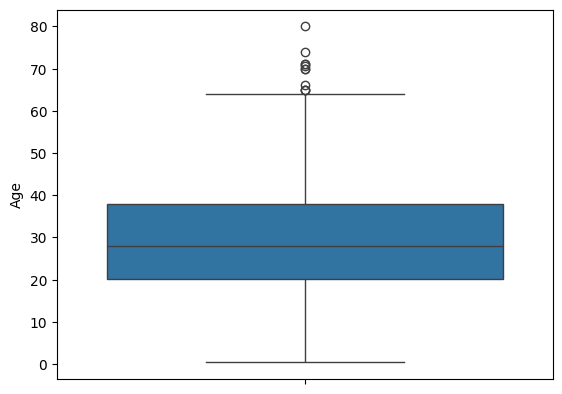

In [9]:
import seaborn as sns
sns.boxplot(df["Age"])

In [10]:
df.Age.fillna(df.Age.median(), inplace=True)

/var/folders/96/pzp77pgj2jngfzbn1nyzz6w80000gn/T/ipykernel_36275/2661029692.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Age.fillna(df.Age.median(), inplace=True)


In [11]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [13]:
df.Embarked.fillna(df.Embarked.mode()[0], inplace=True)

/var/folders/96/pzp77pgj2jngfzbn1nyzz6w80000gn/T/ipykernel_36275/3678395583.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Embarked.fillna(df.Embarked.mode()[0], inplace=True)


In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [15]:
df.Embarked.value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

##feature engineering 

In [16]:
df['Family_size'] = df.Parch + df.SibSp

In [17]:
df['Senior'] = df.Age.apply(lambda x: 1 if x > 60 else 0)
df['Gender_age'] = df.apply(lambda x: "child" if x['Age'] < 15 else x['Sex'], axis=1)

In [18]:
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size,Senior,Gender_age
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,0,male
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,0,female
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,0,female
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,0,female
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,0,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0,0,male
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,0,0,female
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,3,0,female
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,0,0,male


In [19]:
df.Gender_age.value_counts()

Gender_age
male      538
female    275
child      78
Name: count, dtype: int64

In [20]:
df.drop(['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch', 'Sex'], axis=1, inplace=True)

In [21]:
df


,Survived,Pclass,Age,Fare,Embarked,Family_size,Senior,Gender_age
0,0,3,22.0,7.2500,S,1,0,male
1,1,1,38.0,71.2833,C,1,0,female
2,1,3,26.0,7.9250,S,0,0,female
3,1,1,35.0,53.1000,S,1,0,female
4,0,3,35.0,8.0500,S,0,0,male
...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,S,0,0,male
887,1,1,19.0,30.0000,S,0,0,female
888,0,3,28.0,23.4500,S,3,0,female
889,1,1,26.0,30.0000,C,0,0,male


In [22]:
df = pd.get_dummies(df, columns=['Embarked', 'Gender_age'], drop_first=True)

In [23]:
df

,Survived,Pclass,Age,Fare,Family_size,Senior,Embarked_Q,Embarked_S,Gender_age_female,Gender_age_male
0,0,3,22.0,7.2500,1,0,False,True,False,True
1,1,1,38.0,71.2833,1,0,False,False,True,False
2,1,3,26.0,7.9250,0,0,False,True,True,False
3,1,1,35.0,53.1000,1,0,False,True,True,False
4,0,3,35.0,8.0500,0,0,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,0,0,False,True,False,True
887,1,1,19.0,30.0000,0,0,False,True,True,False
888,0,3,28.0,23.4500,3,0,False,True,True,False
889,1,1,26.0,30.0000,0,0,False,False,False,True


In [24]:
from sklearn.model_selection import train_test_split
x = df.drop('Survived', axis=1)
y = df['Survived']

x_train, x_test , y_train , y_test = train_test_split( x, y , test_size=0.2, random_state=42)

print("shape of x_trian:" , x_train.shape)
print("shape of x_test:" , x_test.shape)
print("shape of y_trian:" , y_train.shape)
print("shape of y_test:" , y_test.shape)

shape of x_trian: (712, 9)
shape of x_test: (179, 9)
shape of y_trian: (712,)
shape of y_test: (179,)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index )
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index )




In [26]:
x_train_scaled


,Pclass,Age,Fare,Family_size,Senior,Embarked_Q,Embarked_S,Gender_age_female,Gender_age_male
331,-1.614136,1.253641,-0.078684,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
733,-0.400551,-0.477284,-0.377145,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
382,0.813034,0.215086,-0.474867,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
704,0.813034,-0.246494,-0.476230,0.040096,-0.141624,-0.303355,0.592489,-0.655529,0.802709
813,0.813034,-1.785093,-0.025249,3.013909,-0.141624,-0.303355,0.592489,-0.655529,-1.245781
...,...,...,...,...,...,...,...,...,...
106,0.813034,-0.631144,-0.480162,-0.554666,-0.141624,-0.303355,0.592489,1.525484,-1.245781
270,-1.614136,-0.092634,-0.030545,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
860,0.813034,0.907456,-0.355804,0.634859,-0.141624,-0.303355,0.592489,-0.655529,0.802709
435,-1.614136,-1.169653,1.683201,1.229621,-0.141624,-0.303355,0.592489,-0.655529,-1.245781


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg_model = LogisticRegression( random_state=42)

log_reg_model.fit(x_train_scaled , y_train)

y_pred = log_reg_model.predict(x_test_scaled)

/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

In [28]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1])

In [29]:
y_test

709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64

In [30]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8100558659217877

In [31]:
y_pred_train = log_reg_model.predict(x_train_scaled)
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_train

/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.8314606741573034

In [32]:

# Define lambda values
lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
results = {}

for lam in lambdas:
    C = 1 / lam   # C is inverse of lambda

    model = LogisticRegression(
        C=C,
        random_state=42
    )

    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    results[lam] = acc

    print(f"Lambda: {lam:<6} | C: {C:<8} | Accuracy: {acc:.4f}")

# Best lambda
best_lambda = max(results, key=results.get)
print(f"\nBest Lambda: {best_lambda} with Accuracy: {results[best_lambda]:.4f}")

Lambda: 0.0001 | C: 10000.0  | Accuracy: 0.8101
Lambda: 0.001  | C: 1000.0   | Accuracy: 0.8101
Lambda: 0.01   | C: 100.0    | Accuracy: 0.8101
Lambda: 0.1    | C: 10.0     | Accuracy: 0.8101
Lambda: 1      | C: 1.0      | Accuracy: 0.8101
Lambda: 10     | C: 0.1      | Accuracy: 0.7933

Best Lambda: 0.0001 with Accuracy: 0.8101


/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

In [33]:
x_train, x_test , y_train , y_test = train_test_split( x, y , test_size=0.2, random_state=42)


In [34]:
x_train.shape

(712, 9)

In [35]:
x_test.shape

(179, 9)

In [36]:
x_train, x_val , y_train , y_val = train_test_split( x_train, y_train , test_size=0.2, random_state=42)


In [37]:
x_train.shape

(569, 9)

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled   = scaler.transform(x_val)
x_test_scaled  = scaler.transform(x_test)

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
results = {}

for lam in lambdas:
    C = 1 / lam   # inverse of lambda

    model = LogisticRegression(
        l1_ratio=0,# a pure L2-penalty.
        C=C,


        random_state=42
    )

    # Train on TRAIN set
    model.fit(x_train_scaled, y_train)

    # Validate on VAL set
    y_val_pred = model.predict(x_val_scaled)

    acc = accuracy_score(y_val, y_val_pred)
    results[lam] = acc

    print(f"Lambda: {lam:<6} | C: {C:<8} | Val Accuracy: {acc:.4f}")


Lambda: 0.0001 | C: 10000.0  | Val Accuracy: 0.8252
Lambda: 0.001  | C: 1000.0   | Val Accuracy: 0.8252
Lambda: 0.01   | C: 100.0    | Val Accuracy: 0.8252
Lambda: 0.1    | C: 10.0     | Val Accuracy: 0.8252
Lambda: 1      | C: 1.0      | Val Accuracy: 0.8112
Lambda: 10     | C: 0.1      | Val Accuracy: 0.8182


/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_r

In [41]:
best_lambda = max(results, key=results.get)
best_C = 1 / best_lambda

print(f"\nBest Lambda: {best_lambda}")
print(f"Best Validation Accuracy: {results[best_lambda]:.4f}")


Best Lambda: 0.0001
Best Validation Accuracy: 0.8252


In [42]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [44]:
# Fixed lambda
lambda_val = 0.0001
C = 1 / lambda_val

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(x_train), 1):
    print(f"\nFold {fold}:")
    print("Train size:", len(train_idx))
    print("Val size:", len(val_idx))

    # ✅ USE .iloc
    x_tr = x_train.iloc[train_idx]
    x_val = x_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            penalty='l2',
            C=C,
            max_iter=1000,
            random_state=42
        ))
    ])

    model.fit(x_tr, y_tr)
    y_val_pred = model.predict(x_val)

    acc = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Fold 1:
Train size: 455
Val size: 114
Fold 1 Accuracy: 0.7544

Fold 2:
Train size: 455
Val size: 114
Fold 2 Accuracy: 0.8684

Fold 3:
Train size: 455
Val size: 114
Fold 3 Accuracy: 0.8421

Fold 4:
Train size: 455
Val size: 114
Fold 4 Accuracy: 0.8421

Fold 5:
Train size: 456
Val size: 113
Fold 5 Accuracy: 0.8319


/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point